In [38]:
import sys, os
sys.path.append(os.path.abspath("../../"))

# Load shared utilities for attention-from-scratch analysis
from scripts.attention_from_scratch_utils import *

# Set reproducible seed
set_seed(42)

print("Environment ready.")
print("Device:", device)

Environment ready.
Device: mps


# Dimensions in Token Embeddings

A "token embedding" means that each word or symbol is represented as a vector of numbers. Each number in that vector is a “dimension,” forming an informational space where meanings and relationships are encoded.

---

### What Does a Dimension Represent?

- Each dimension is a numerical feature the model uses to capture meaning.
- Single dimensions rarely map directly to human ideas (not “animal-ness”, “past-tense”, etc.).
- All dimensions are learned automatically and represent useful patterns for predicting language.
- Abstract features only become meaningful when combined, creating complex word associations.
- You can picture dimensions as “dials” the model tunes to encode unique properties of each word.

---

### Why Use Only 2 Dimensions for Learning?

- Real models use 512–4096 dimensions for rich meaning, but these are impossible to visualize directly.
- In teaching, we use 2-dimensional embeddings as a toy example:
  - Dimensions are manually set or random, not learned by the model.
  - Their purpose is to make mathematical operations (like dot products, similarity, scaling, or attention) easy to visualize.
- This simplification helps understand core concepts before scaling up to real models.

---

### Example: 4-Dimensional Toy Embedding

Suppose a tiny vocabulary with 3 tokens ("cat", "dog", "run") and each token has a 4-dimensional embedding vector:

| Token | Embedding Vector         |
|-------|-------------------------|
| cat   | [0.7, -0.2, 0.1, 0.8]   |
| dog   | [0.6, -0.1, 0.0, 0.7]   |
| run   | [0.0, 0.3, -0.5, 0.1]   |

Here, each number (e.g., 0.7 in “cat”) represents a different dimension. The similarity between “cat” and “dog” could be calculated by seeing how close these vectors are in the 4-dimensional space.

---

### Summary

- A dimension is one value in the embedding vector for each token.
- Real models learn hundreds or thousands of dimensions for nuanced representation.
- Toy examples use 2–4 dimensions for educational visualization.
- Dimensions don’t represent explicit concepts, but rather help encode the abstract features needed for models to “understand” language.


# 01 — Scaled Dot-Product Attention (From Scratch)

In this notebook, we build the core operation behind transformers: **scaled dot-product attention** — the mechanism that allows models like GPT to decide which tokens matter most in a sequence.

### What we'll explore
- The mathematical definition of attention  
- Creating queries (Q), keys (K), and values (V)  
- Computing attention step-by-step (no deep learning frameworks)  
- Understanding the role of the scaling factor $ \sqrt{d_k} $  
- Visualizing attention weights  

By the end of this notebook, you’ll fully understand the core computation powering all transformer architectures.

## Tokens, Queries, and Keys

To make attention intuitive, we start with a simple sentence:

**The cat chased the mouse**

In a real transformer, each token is first turned into an embedding, then three learned projection matrices create:

- **Query (Q)** — what this token is *looking for*  
- **Key (K)** — what this token *offers* to others  
- **Value (V)** — the information this token will contribute  

In this notebook, we use small, handcrafted 2-dimensional vectors for clarity.

## Step 1 — Computing Similarity (Dot Products)

Attention begins by asking:

> **“How similar is my Query vector to every Key vector?”**

For each token, we compare its **Query** vector to every **Key** vector using the **dot product**.

If a Query vector is $ q = [q_1, q_2, \dots, q_d] $ and a Key vector is $ k = [k_1, k_2, \dots, k_d] $,  
their similarity score is simply:

$ q \cdot k = q_1 k_1 + q_2 k_2 + \dots + q_d k_d $

We do this for **every Query against every Key**, which produces the full similarity matrix:

$ \text{scores} = QK^\top $

Where each entry $ \text{scores}_{i,j} $ tells us:

> **“How much does token *i* (as a Query) relate to token *j* (as a Key)?”**

- High value → strong relationship  
- Low value → weak relationship

In [39]:
import numpy as np
import pandas as pd

tokens = ["The", "cat", "chased", "the", "mouse"]

# Simple fake Q and K vectors (2D)
Q = {
    "The":    np.array([1, 0]),
    "cat":    np.array([1, 1]),
    "chased": np.array([0, 1]),
    "the":    np.array([1, 0]),
    "mouse":  np.array([0, 1])
}

K = {
    "The":    np.array([1, 0]),
    "cat":    np.array([1, 1]),
    "chased": np.array([0, 1]),
    "the":    np.array([1, 0]),
    "mouse":  np.array([0, 1])
}

# Build similarity matrix using dot products (Q · Kᵀ)
matrix = []
for q_tok in tokens:
    row = []
    for k_tok in tokens:
        row.append(Q[q_tok] @ K[k_tok])
    matrix.append(row)

df = pd.DataFrame(matrix, index=tokens, columns=tokens)
df

,The,cat,chased,the,mouse
The,1,1,0,1,0
cat,1,2,1,1,1
chased,0,1,1,0,1
the,1,1,0,1,0
mouse,0,1,1,0,1


## Step 2 — Scaling the Scores

Before applying softmax, we scale the dot products by the factor $ \sqrt{d_k} $,  
where $ d_k $ is the dimensionality of the key vectors (2 in this example).

### Why scale?

As vector dimensionality increases, dot products grow larger even when vectors aren't truly similar.  
Large values cause softmax to become **too sharp**, making the model overly confident.

Scaling by $ \sqrt{d_k} $ keeps scores in a stable range so softmax produces **smooth, meaningful** attention weights.

In [40]:
d_k = 2   # dimension of each key vector
scaled = df / np.sqrt(d_k)
scaled

,The,cat,chased,the,mouse
The,0.707107,0.707107,0.000000,0.707107,0.000000
cat,0.707107,1.414214,0.707107,0.707107,0.707107
chased,0.000000,0.707107,0.707107,0.000000,0.707107
the,0.707107,0.707107,0.000000,0.707107,0.000000
mouse,0.000000,0.707107,0.707107,0.000000,0.707107


## Step 3 — Softmax: Turning Scores Into Attention Weights

After scaling our similarity scores, we apply **softmax** to each row of the matrix.  
This is the step where our raw numbers become **attention weights**.

### What does softmax do?

Softmax converts a list of numbers into a **probability distribution**, meaning:

- All values become **positive**
- Each row **sums to 1**
- Larger numbers become **larger weights**
- Smaller numbers become **smaller weights**

**each row is normalized to add up to 1.**

---

### Why is that useful?

Each row represents all the other tokens a particular token is comparing itself to.

Softmax answers:

> **“Given these similarity scores, how much should this token pay attention to each other token?”**

Because each row sums to 1,  
the values can be interpreted like **percentages** or **fractions of attention**.

For example:

- A weight of **0.60** means “pay strong attention to this token”
- A weight of **0.05** means “barely pay attention to this token”
- A weight of **0.00** means “ignore this token”

---

### Intuition

Softmax highlights the important tokens and fades out the irrelevant ones.

It takes the raw scores from $ QK^\top $ and turns them into meaningful **focus weights** that the model will use in the next step (the weighted sum with Value vectors).

---

### Output

The result of this step is the **attention weight matrix** — the matrix you later visualize as a heatmap.

In [43]:
# --- Step 3: Apply Softmax to each row ---

def softmax(x):
    # subtract max for numerical stability
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# convert scaled scores (a DataFrame) to numpy
scaled_scores = scaled.values

attention_weights = softmax(scaled_scores)

# Convert to a DataFrame
df_attention = pd.DataFrame(attention_weights, index=tokens, columns=tokens)

# --- NEW: Add a "row_sum" column so we can see the values add to 1 ---
df_attention["row_sum"] = df_attention.sum(axis=1)

df_attention

,The,cat,chased,the,mouse,row_sum
The,0.250869,0.250869,0.123696,0.250869,0.123696,1.0
cat,0.165889,0.336443,0.165889,0.165889,0.165889,1.0
chased,0.123696,0.250869,0.250869,0.123696,0.250869,1.0
the,0.250869,0.250869,0.123696,0.250869,0.123696,1.0
mouse,0.123696,0.250869,0.250869,0.123696,0.250869,1.0


## Step 4 — Weighted Sum of Values (V)

Now that we have the attention weights, the final step is to turn these weights into **useful information**.  
This is where the **Value vectors (V)** come in.

### Why do we use Value vectors?

- **Q and K decide the attention pattern**  
  → “Who should I pay attention to?”

- **V carries the actual information we want to share**  
  → “What information should I take from them?”

So the Values contain the *content* that gets passed between tokens.

---

### What happens in this step?

For each token:

1. Take its row of attention weights (which sum to 1).  
2. Multiply each weight by the corresponding Value vector.  
3. Add all those weighted Value vectors together.

This produces a new, **context-aware vector**.

Mathematically:

$ \text{output}_i = \sum_j \text{attention\_weight}_{i,j} \cdot v_j $

This is just a **weighted average** of all the Value vectors.

---

### Why is this important?

This is the moment where attention becomes meaningful:

- Tokens gather information from the tokens they attend to most.  
- Irrelevant tokens contribute almost nothing.  
- Each token transforms from an isolated embedding into a **contextual embedding**.

This is how transformers build understanding:

> **Tokens rewrite their meaning based on the context around them.**

The result of this step is the **final attention output** for each token.

In [46]:
# --- Step 4: Create Value vectors (V) ---

V = {
    "The":    np.array([0.1, 0.0]),
    "cat":    np.array([1.0, 0.5]),
    "chased": np.array([0.3, 0.9]),
    "the":    np.array([0.1, 0.0]),
    "mouse":  np.array([0.9, 0.2])
}

# Stack V vectors in the same order as the tokens
V_matrix = np.vstack([V[tok] for tok in tokens])

print("Value (V) matrix:")
display(pd.DataFrame(V_matrix, index=tokens, columns=["v1", "v2"]))

# --- Compute the final attention output ---
# Each token gathers information using a weighted sum of the V vectors
output = attention_weights @ V_matrix

df_output = pd.DataFrame(output, index=tokens, columns=["out1", "out2"])

print("\nFinal attention output (contextualized vectors):")
df_output

Value (V) matrix:


,v1,v2
The,0.1,0.0
cat,1.0,0.5
chased,0.3,0.9
the,0.1,0.0
mouse,0.9,0.2



Final attention output (contextualized vectors):


,out1,out2
The,0.449478,0.261500
cat,0.568688,0.350700
chased,0.576652,0.401391
the,0.449478,0.261500
mouse,0.576652,0.401391


## Visualizing Attention (Heatmap)

A heatmap helps us see attention patterns clearly:

- **Rows = Query tokens (who is attending)**  
- **Columns = Key tokens (who is being attended to)**  
- Brighter colors = stronger attention  
- Darker colors = weaker attention  

This is exactly how attention maps are visualized in real transformer models.

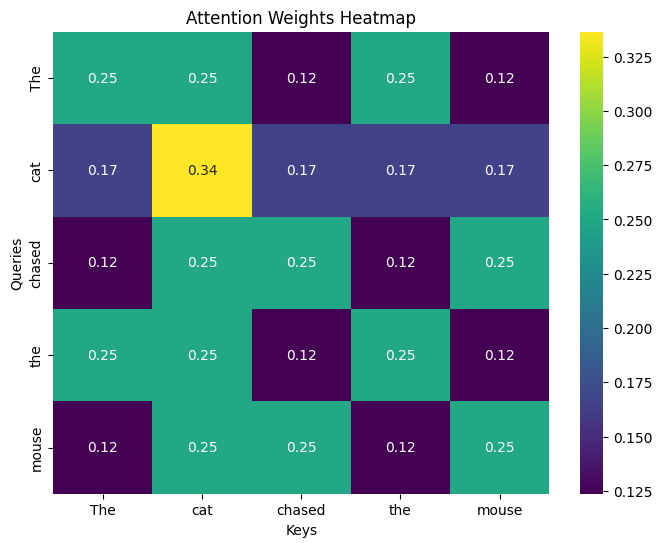

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_weights,
    xticklabels=tokens,
    yticklabels=tokens,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)
plt.title("Attention Weights Heatmap")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()

## Recap — Scaled Dot-Product Attention

Here’s the entire process in one place:

1. **Dot products:**  
   Compute $ QK^\top $ to measure similarity between queries and keys.

2. **Scale:**  
   Divide by $ \sqrt{d_k} $ to keep softmax stable and avoid overly large values.

3. **Softmax:**  
   Convert scores into a probability distribution — attention weights.

4. **Weighted sum:**  
   Multiply weights by Value vectors to produce the final attention output.

---

## Intuition Summary

- **Q** = what a token is looking for  
- **K** = what a token offers  
- **V** = the information a token carries  

Attention is simply:

> **“Look at the tokens that matter most, and blend their information into my representation.”**

This simple mechanism forms the foundation of all transformer architectures.

## Bridging the Gap — From Our 2D Example to a Real Transformer

So far, we've built scaled dot-product attention entirely from scratch using small 2-dimensional vectors.  
This made the intuition crystal clear: Queries look for Keys, softmax chooses who to focus on, and Values carry information.

But what happens inside a **real transformer**, such as BERT, GPT-2, or any modern LLM?

Let’s walk through how attention is computed on our real sentence:

**“The cat chased the mouse.”**

### What changes in a real transformer?

- **Token embeddings** are high dimensional (e.g., 768 → BERT-base).  
- The model learns matrices $W_Q$, $W_K$, and $W_V$ during training.  
- Queries, Keys, and Values are computed automatically for each layer and head.  
- Multiple heads analyze different relationships (syntax, semantics, subject/object, determiners, etc.).  
- Attention maps become more complex — but the math is *identical* to what we built.

### What stays the same?

- Dot products still measure similarity  
- We still scale by $ \sqrt{d_k} $  
- Softmax still creates attention weights  
- Values are still blended by a weighted sum  
- The equation is still:

$ \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V $

### Our goal now

To **visualize the real attention** produced by a small transformer model on our sentence,  
so you can see how closely it mirrors the logic of our handcrafted example.

Below, we use a small HuggingFace model to extract and display the actual attention maps.

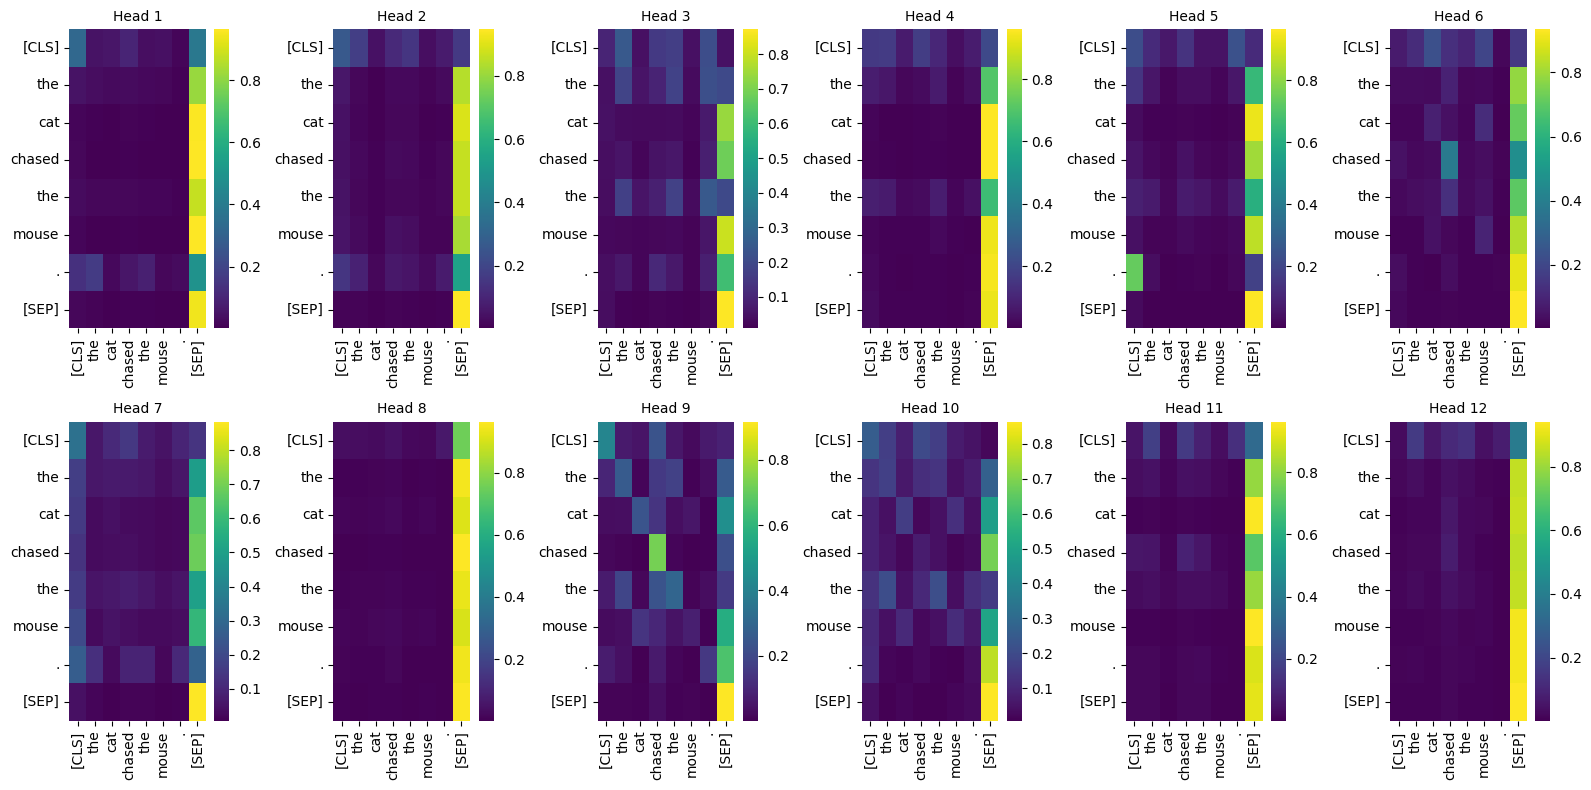

In [34]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Load a small pre-trained model (BERT-base)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

sentence = "The cat chased the mouse."
inputs = tokenizer(sentence, return_tensors="pt")
outputs = model(**inputs)

# Extract attention from the last layer
attentions = outputs.attentions[-1]   # shape: (batch, heads, seq_len, seq_len)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
num_heads = attentions.shape[1]

plt.figure(figsize=(16, 8))

for i in range(num_heads):
    plt.subplot(2, num_heads//2, i+1)
    sns.heatmap(attentions[0, i].detach().numpy(), 
                xticklabels=tokens, 
                yticklabels=tokens, 
                cmap="viridis")
    plt.title(f"Head {i+1}", fontsize=10)

plt.tight_layout()
plt.show()